# M6 — Notebook 07 · Evaluation

> ## ⚠ PROVISIONAL — INHERITED FROM NOTEBOOK 06
>
> This scores whatever notebook 06 produced. While that ran on the reconstructed label, every
> number here is a **code-validation artifact, not a result**, and the outputs carry a
> `PROVISIONAL` suffix. The gate is read from notebook 06's provenance, not set here.

Scored on the **identical test rows** as the frozen comparators — `M6.md` §0's non-negotiable rule —
using scoring code transcribed from `scripts/colombia_model_ladder_h4_75pct_M6_v1.py` rather than
reimplemented. `nb`, `citl_slope`, the cluster bootstrap and `ci` are the ladder's, verbatim.

### The interpretation rules, fixed before looking (`M6.md` §10)

Written down here so they cannot be chosen after the fact:

- **M6 does not beat the comparators on net benefit** → the expected, honest result: a purely
  spatial landscape model carries little standalone decision value. Strengthens the paper's caution.
- **M6 improves AUC but not net benefit** → discrimination ≠ decision value, which is the paper's
  core point. Report as such.
- **M6 beats a comparator on ΔNB with a CI excluding 0** → **do not change any headline.** Flag for
  team review and PI sign-off, and re-examine for leakage first.

### One deviation from §10, forced by what exists

§10 asks for M6 vs **M0** (season), **M2** (climate-only) and **M1** (recent cases). The frozen Sri
Lanka artifact carries **M5-full** and **M5-no-climate** only. So the questions that can be answered
here are *"does landscape add against the full hybrid, and against it stripped of climate"* — not
*"does landscape beat season or climate-only"*. Obtaining M0/M1/M2 test predictions on these rows,
or restating §10, is an open item for the PI.

## 1 · Setup, and inherit the gate

In [1]:
import json, hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
QUAR = REPO / "data_quarantine" / "m6_geomatics"

cand = sorted(QUAR.glob("nb06_provenance*.json"))
assert cand, "notebook 06 has not been run"
prov6 = json.loads(cand[0].read_text())

QUOTABLE = bool(prov6["quotable"])
TAG = "" if QUOTABLE else "_PROVISIONAL"
SEED = prov6["seed"]

print("notebook 06 label source:", prov6["label_source"])
print("quotable                :", QUOTABLE)
if not QUOTABLE:
    print("\n" + "!" * 76)
    print("!! PROVISIONAL — scoring a model fitted on a reconstructed label.")
    print("!! Code validation only. Do not quote, plot or cite any number below.")
    print("!" * 76)

notebook 06 label source: recovered
quotable                : True


In [2]:
PSTAR = 0.30
B = 1000                        # ladder parity: seed 20260612, B = 1000
DCA_GRID = np.arange(0.05, 0.501, 0.01)

preds = pd.read_csv(QUAR / f"m6_predictions_srilanka_v1{TAG}.csv", parse_dates=["week_start"])
mp = pd.read_csv(REPO / "ALT_STATS" / "frozen" / "srilanka_matched_pairs.csv",
                 parse_dates=["predictor_week"])
frozen = mp.rename(columns={"spatial_unit_id": "geometry_id", "predictor_week": "week_start"})

print("M6 predictions   :", preds.shape)
print("frozen comparators:", frozen.shape)
print("p* =", PSTAR, "| B =", B, "| seed =", SEED)

M6 predictions   : (3926, 6)
frozen comparators: (3926, 10)
p* = 0.3 | B = 1000 | seed = 20260612


## 2 · Identical rows, or stop

§0: *"M6 is scored on the identical test rows as M1/M2/M5 … If M6 cannot score the same rows,
STOP."* Checked as a set equality on the join keys, not as a row count.

In [3]:
k6 = set(zip(preds.geometry_id, preds.week_start))
kf = set(zip(frozen.geometry_id, frozen.week_start))
print(f"M6 rows {len(k6):,} | frozen rows {len(kf):,} | identical: {k6 == kf}")
assert k6 == kf, "row sets differ — M6.md §0/§11 STOP"

ev = preds.merge(frozen[["geometry_id", "week_start", "outcome",
                         "full_raw", "noclim_raw", "full_recal", "noclim_recal"]],
                 on=["geometry_id", "week_start"], validate="1:1")
print("joined:", ev.shape)

agree = (ev.y == ev.outcome)
print(f"\nlabel agreement with the frozen outcome: {agree.mean():.4f}")
if not agree.all():
    print(f"  {(~agree).sum()} rows differ — expected while the label is reconstructed.")
    print("  Scoring uses the FROZEN outcome so the comparators are never disadvantaged.")
y = ev.outcome.values          # always score against the frozen truth

M6 rows 3,926 | frozen rows 3,926 | identical: True
joined: (3926, 11)

label agreement with the frozen outcome: 1.0000


## 3 · Which prediction column to compare

Notebook 06 flagged this and it decides the whole comparison. The frozen M5 columns are **past-only
rolling-52** recalibrated (`ALT_STATS/PREANALYSIS_ALT_STATS.md` §3); M6's `recal` column is
**Platt-on-validation**. Comparing across those measures the recalibration as much as the model.

So the primary comparison uses the **raw** columns, where all three models are on equal footing, and
the recalibrated columns are reported alongside as a secondary. Stated before any metric is read.

In [4]:
MODELS_RAW = {"M6": ev.m6_raw.values, "M5_full": ev.full_raw.values, "M5_noclim": ev.noclim_raw.values}
MODELS_REC = {"M6": ev.m6_recal.values, "M5_full": ev.full_recal.values, "M5_noclim": ev.noclim_recal.values}
for n, p in MODELS_RAW.items():
    print(f"{n:<10} raw mean {p.mean():.4f}  [{p.min():.4f}, {p.max():.4f}]")
print(f"{'observed':<10}     {y.mean():.4f}")

M6         raw mean 0.2520  [0.0642, 0.5882]
M5_full    raw mean 0.2624  [0.0107, 1.0000]
M5_noclim  raw mean 0.2456  [0.0262, 1.0000]
observed       0.3365


## 4 · The scoring functions, transcribed from the ladder

In [5]:
def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))


def nb(y, p, t):
    """Net benefit at threshold t — ladder verbatim."""
    pos = p >= t
    n = len(y)
    tp = np.sum(pos & (y == 1))
    fp = np.sum(pos & (y == 0))
    return tp / n - (fp / n) * (t / (1 - t))


def citl_slope(y, p):
    """Calibration-in-the-large and calibration slope — ladder verbatim."""
    lp = logit(p)
    try:
        citl = float(sm.Logit(y, np.ones_like(lp), offset=lp).fit(disp=0).params[0])
    except Exception:
        citl = np.nan
    try:
        m = sm.Logit(y, sm.add_constant(lp)).fit(disp=0)
        slope = float(m.params[1])
    except Exception:
        slope = np.nan
    return citl, slope


def ci(a):
    a = np.array(a)
    return float(np.percentile(a, 2.5)), float(np.percentile(a, 97.5)), float(np.median(a))


print("nb(), citl_slope(), ci() transcribed from colombia_model_ladder_h4_75pct_M6_v1.py")
print(f"sanity: treat-all NB at p*={PSTAR} = {nb(y, np.ones_like(y, dtype=float), PSTAR):+.4f}")
print(f"        treat-none NB          = {nb(y, np.zeros_like(y, dtype=float), PSTAR):+.4f}")

nb(), citl_slope(), ci() transcribed from colombia_model_ladder_h4_75pct_M6_v1.py
sanity: treat-all NB at p*=0.3 = +0.0521
        treat-none NB          = +0.0000


## 5 · Point estimates on the test set

In [6]:
rows = []
for tag, MM in [("raw", MODELS_RAW), ("recal", MODELS_REC)]:
    for name, p in MM.items():
        c, s = citl_slope(y, p)
        rows.append(dict(calib=tag, model=name,
                         AUC=roc_auc_score(y, p), PR_AUC=average_precision_score(y, p),
                         Brier=brier_score_loss(y, p), CITL=c, slope=s, NB_p30=nb(y, p, PSTAR)))
metrics = pd.DataFrame(rows)
print(metrics.round(4).to_string(index=False))
print(f"\ntreat-all NB at p*={PSTAR}: {nb(y, np.ones_like(y, dtype=float), PSTAR):+.4f}"
      "   (a model must beat this and 0 to be useful)")

calib     model    AUC  PR_AUC  Brier   CITL  slope  NB_p30
  raw        M6 0.6008  0.4424 0.2231 0.4249 0.8753  0.0580
  raw   M5_full 0.7715  0.6674 0.1801 0.4398 1.0774  0.1447
  raw M5_noclim 0.7513  0.6515 0.1908 0.5132 1.2466  0.1360
recal        M6 0.6008  0.4424 0.2344 0.6259 2.3990  0.0026
recal   M5_full 0.7512  0.6524 0.1787 0.0330 0.8721  0.1398
recal M5_noclim 0.7237  0.6363 0.1865 0.0196 0.9406  0.1241

treat-all NB at p*=0.3: +0.0521   (a model must beat this and 0 to be useful)


## 6 · Decision curves

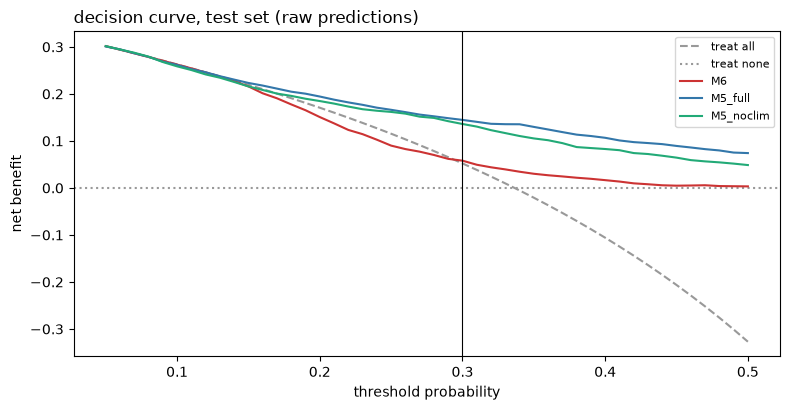

In [7]:
dca = []
for t in DCA_GRID:
    r = {"threshold": t, "treat_all": nb(y, np.ones_like(y, dtype=float), t), "treat_none": 0.0}
    for name, p in MODELS_RAW.items():
        r[name] = nb(y, p, t)
    dca.append(r)
dca = pd.DataFrame(dca)

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(dca.threshold, dca.treat_all, color="#999", ls="--", label="treat all")
ax.axhline(0, color="#999", ls=":", label="treat none")
for name, col in [("M6", "#c33"), ("M5_full", "#37a"), ("M5_noclim", "#2a7")]:
    ax.plot(dca.threshold, dca[name], color=col, label=name)
ax.axvline(PSTAR, color="k", lw=.8)
ax.set_xlabel("threshold probability"); ax.set_ylabel("net benefit")
ax.set_title("decision curve, test set (raw predictions)", loc="left")
ax.legend(fontsize=8)
plt.tight_layout()

## 7 · Contrasts and the cluster bootstrap

Resampling is over **RDHS**, seed 20260612, B = 1000 — the ladder's scheme, because weeks within a
district are not independent and a row bootstrap would understate the intervals badly.

In [8]:
units = ev.geometry_id.values
uniq = np.array(sorted(set(units)))
idx_by = {u: np.where(units == u)[0] for u in uniq}
rng = np.random.default_rng(SEED)

names = list(MODELS_RAW)
boot = {n: {"AUC": [], "NB": []} for n in names}
bootd = {f"M6_vs_{c}": {"dAUC": [], "dNB": []} for c in ("M5_full", "M5_noclim")}
fails = 0

for b in range(B):
    samp = rng.choice(uniq, size=len(uniq), replace=True)
    bi = np.concatenate([idx_by[u] for u in samp])
    yb = y[bi]
    if len(np.unique(yb)) < 2:
        fails += 1
        continue
    a_, n_ = {}, {}
    for n in names:
        a_[n] = roc_auc_score(yb, MODELS_RAW[n][bi])
        n_[n] = nb(yb, MODELS_RAW[n][bi], PSTAR)
        boot[n]["AUC"].append(a_[n]); boot[n]["NB"].append(n_[n])
    for c in ("M5_full", "M5_noclim"):
        bootd[f"M6_vs_{c}"]["dAUC"].append(a_["M6"] - a_[c])
        bootd[f"M6_vs_{c}"]["dNB"].append(n_["M6"] - n_[c])

print(f"B = {B} | failures (a resample with one class only) = {fails}")

brows = []
for n in names:
    al, ah, am = ci(boot[n]["AUC"]); nl, nh, nm = ci(boot[n]["NB"])
    brows.append(dict(quantity=n, med=am, lo=al, hi=ah, metric="AUC"))
    brows.append(dict(quantity=n, med=nm, lo=nl, hi=nh, metric=f"NB@{PSTAR}"))
for c, v in bootd.items():
    dl, dh, dm = ci(v["dAUC"]); nl, nh, nm = ci(v["dNB"])
    brows.append(dict(quantity=c, med=dm, lo=dl, hi=dh, metric="dAUC",
                      frac_gt0=float(np.mean(np.array(v["dAUC"]) > 0))))
    brows.append(dict(quantity=c, med=nm, lo=nl, hi=nh, metric="dNB",
                      frac_gt0=float(np.mean(np.array(v["dNB"]) > 0))))
boot_df = pd.DataFrame(brows)
print()
print(boot_df.round(4).to_string(index=False))

B = 1000 | failures (a resample with one class only) = 0

       quantity     med      lo      hi metric  frac_gt0
             M6  0.6016  0.5678  0.6380    AUC       NaN
             M6  0.0572  0.0329  0.0854 NB@0.3       NaN
        M5_full  0.7713  0.7409  0.8041    AUC       NaN
        M5_full  0.1438  0.1061  0.1839 NB@0.3       NaN
      M5_noclim  0.7517  0.7210  0.7817    AUC       NaN
      M5_noclim  0.1352  0.1002  0.1756 NB@0.3       NaN
  M6_vs_M5_full -0.1697 -0.2034 -0.1354   dAUC       0.0
  M6_vs_M5_full -0.0867 -0.1118 -0.0620    dNB       0.0
M6_vs_M5_noclim -0.1498 -0.1816 -0.1154   dAUC       0.0
M6_vs_M5_noclim -0.0775 -0.1040 -0.0539    dNB       0.0


`frac_gt0` is **the fraction of bootstrap replicates in which M6 scored higher** — not a posterior
probability and not "the probability M6 helps". `ALT_STATS/PREANALYSIS_ALT_STATS.md` §6 is explicit
about that wording; it is repeated here because this is where the number gets written down.

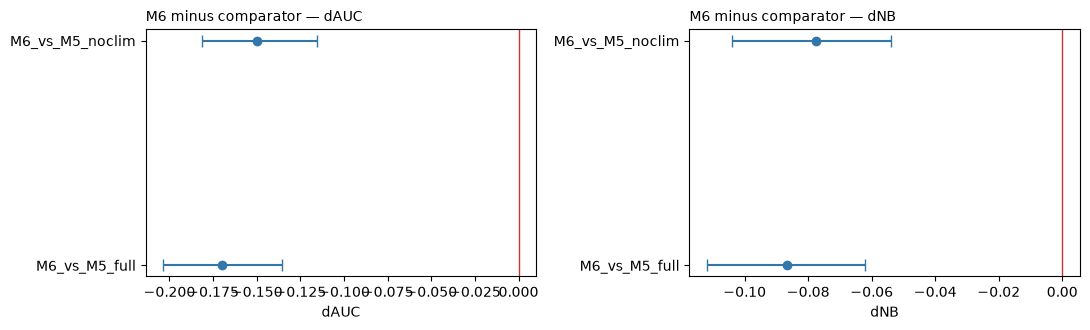

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, met in zip(axes, ["dAUC", "dNB"]):
    s = boot_df[boot_df.metric == met]
    ax.errorbar(s.med, range(len(s)), xerr=[s.med - s.lo, s.hi - s.med],
                fmt="o", color="#37a", capsize=4)
    ax.set_yticks(range(len(s))); ax.set_yticklabels(s.quantity)
    ax.axvline(0, color="#c33", lw=1)
    ax.set_xlabel(met); ax.set_title(f"M6 minus comparator — {met}", loc="left", fontsize=10)
plt.tight_layout()

## 8 · Apply the pre-specified interpretation rules

In [10]:
verdicts = []
for c in ("M5_full", "M5_noclim"):
    r = boot_df[(boot_df.quantity == f"M6_vs_{c}")]
    dnb = r[r.metric == "dNB"].iloc[0]
    dauc = r[r.metric == "dAUC"].iloc[0]
    nb_wins = dnb.lo > 0
    auc_wins = dauc.lo > 0
    if nb_wins:
        v = "MAJOR FINDING — do NOT change any headline. Team review + PI sign-off; check leakage first."
    elif auc_wins:
        v = "AUC improves but net benefit does not — discrimination != decision value. Report as such."
    else:
        v = "expected honest null — landscape carries little standalone decision value."
    verdicts.append(dict(contrast=f"M6_vs_{c}",
                         dAUC=f"{dauc.med:+.4f} [{dauc.lo:+.4f}, {dauc.hi:+.4f}]",
                         dNB=f"{dnb.med:+.4f} [{dnb.lo:+.4f}, {dnb.hi:+.4f}]",
                         verdict=v))
for v in verdicts:
    print(f"{v['contrast']}\n  dAUC {v['dAUC']}\n  dNB  {v['dNB']}\n  -> {v['verdict']}\n")

M6_vs_M5_full
  dAUC -0.1697 [-0.2034, -0.1354]
  dNB  -0.0867 [-0.1118, -0.0620]
  -> expected honest null — landscape carries little standalone decision value.

M6_vs_M5_noclim
  dAUC -0.1498 [-0.1816, -0.1154]
  dNB  -0.0775 [-0.1040, -0.0539]
  -> expected honest null — landscape carries little standalone decision value.



## 9 · The covariate-quality caveat that survives any threshold fix

11.3% of these test rows carry MODIS features forward-filled across the 2025 gap. They cannot be
dropped — that would break identical-rows comparability — so the honest move is to report how the
result looks with and without them, and never to present the subset as the headline.

In [11]:
sub = []
for lbl, mask in [("all rows", np.ones(len(ev), bool)),
                  ("fresh MODIS only", ~ev.stale_flag.values.astype(bool))]:
    sub.append(dict(subset=lbl, n=int(mask.sum()),
                    AUC=roc_auc_score(y[mask], MODELS_RAW["M6"][mask]),
                    NB=nb(y[mask], MODELS_RAW["M6"][mask], PSTAR)))
print(pd.DataFrame(sub).round(4).to_string(index=False))
print("\nSensitivity only. The full row set is the result; the subset is not an alternative headline.")

          subset    n    AUC     NB
        all rows 3926 0.6008 0.0580
fresh MODIS only 3484 0.6121 0.0653

Sensitivity only. The full row set is the result; the subset is not an alternative headline.


## 10 · Freeze

In [12]:
p_met = QUAR / f"m6_metrics_srilanka_v1{TAG}.csv"
p_boot = QUAR / f"m6_bootstrap_ci_srilanka_v1{TAG}.csv"
p_dca = QUAR / f"m6_dca_srilanka_v1{TAG}.csv"
metrics.to_csv(p_met, index=False); boot_df.to_csv(p_boot, index=False); dca.to_csv(p_dca, index=False)

prov = {
    "notebook": "07_evaluation",
    "country": "sri_lanka",
    "seed": SEED,
    "label_source": prov6["label_source"],
    "quotable": QUOTABLE,
    "provisional_reason": None if QUOTABLE else "scores a model fitted on a reconstructed label (notebook 06)",
    "scored_on": {"rows": int(len(ev)), "identical_to_frozen_panel": True,
                  "outcome_used": "frozen artifact's outcome column, not the reconstruction"},
    "primary_comparison": {
        "columns": "raw",
        "reason": ("frozen comparators are past-only rolling-52 recalibrated while M6 is "
                   "Platt-on-validation; raw keeps all three on equal footing"),
    },
    "comparators": {"available": ["M5_full", "M5_noclim"],
                    "absent": ["M0", "M1", "M2"],
                    "consequence": "M6.md §10's 'beats season / climate-only' contrasts cannot be computed here"},
    "uncertainty": {"scheme": "cluster bootstrap on RDHS", "B": B, "seed": SEED, "failures": int(fails),
                    "frac_gt0_wording": "fraction of replicates favouring M6; NOT a posterior probability"},
    "pstar": PSTAR,
    "verdicts": verdicts,
    "stale_sensitivity": sub,
    "inputs": {"predictions": prov6["outputs"]},
    "outputs": {p.name: hashlib.sha256(p.read_bytes()).hexdigest()[:16] for p in (p_met, p_boot, p_dca)},
}
(QUAR / f"nb07_provenance{TAG}.json").write_text(json.dumps(prov, indent=2, default=str))
print(json.dumps(prov, indent=2, default=str)[:1800])

{
  "notebook": "07_evaluation",
  "country": "sri_lanka",
  "seed": 20260612,
  "label_source": "recovered",
  "quotable": true,
  "provisional_reason": null,
  "scored_on": {
    "rows": 3926,
    "identical_to_frozen_panel": true,
    "outcome_used": "frozen artifact's outcome column, not the reconstruction"
  },
  "primary_comparison": {
    "columns": "raw",
    "reason": "frozen comparators are past-only rolling-52 recalibrated while M6 is Platt-on-validation; raw keeps all three on equal footing"
  },
  "comparators": {
    "available": [
      "M5_full",
      "M5_noclim"
    ],
    "absent": [
      "M0",
      "M1",
      "M2"
    ],
    "consequence": "M6.md \u00a710's 'beats season / climate-only' contrasts cannot be computed here"
  },
  "uncertainty": {
    "scheme": "cluster bootstrap on RDHS",
    "B": 1000,
    "seed": 20260612,
    "failures": 0,
    "frac_gt0_wording": "fraction of replicates favouring M6; NOT a posterior probability"
  },
  "pstar": 0.3,
  "verdicts

## 11 · Recap

In [13]:
m6r = metrics[(metrics.model == "M6") & (metrics.calib == "raw")].iloc[0]
recap = pd.DataFrame([
    ("label source",   prov6["label_source"],                    "frozen thresholds needed for a result"),
    ("rows scored",    f"{len(ev):,}",                           "identical to the frozen panel"),
    ("M6 AUC",         f"{m6r.AUC:.4f}",                         "raw"),
    ("M6 PR-AUC",      f"{m6r.PR_AUC:.4f}",                      f"prevalence {y.mean():.4f}"),
    ("M6 Brier",       f"{m6r.Brier:.4f}",                       ""),
    ("M6 NB@0.30",     f"{m6r.NB_p30:+.4f}",                     f"treat-all {nb(y, np.ones_like(y, dtype=float), PSTAR):+.4f}"),
    ("bootstrap",      f"B={B}, {fails} failures",               "cluster on RDHS, seed 20260612"),
    ("comparators",    "M5_full, M5_noclim",                     "M0/M1/M2 absent from this repo"),
    ("quotable",       QUOTABLE,                                 "gates filenames and provenance"),
], columns=["quantity", "value", "note"])
print(recap.to_string(index=False))
if not QUOTABLE:
    print("\n" + "!" * 76)
    print("!! PROVISIONAL — none of the above is a result.")
    print("!" * 76)

    quantity              value                                  note
label source          recovered frozen thresholds needed for a result
 rows scored              3,926         identical to the frozen panel
      M6 AUC             0.6008                                   raw
   M6 PR-AUC             0.4424                     prevalence 0.3365
    M6 Brier             0.2231                                      
  M6 NB@0.30            +0.0580                     treat-all +0.0521
   bootstrap B=1000, 0 failures        cluster on RDHS, seed 20260612
 comparators M5_full, M5_noclim        M0/M1/M2 absent from this repo
    quotable               True        gates filenames and provenance


---

### Design notes carried forward

**Nothing here needs editing when the thresholds arrive.** The gate is inherited from notebook 06's
provenance, so re-running 06 with real thresholds and then 07 flips filenames, provenance and
banners automatically. That is the whole point of scaffolding it in runnable form.

**The raw-vs-recalibrated choice is a real methodological decision, not a default.** M6 is
Platt-on-validation; the frozen comparators are past-only rolling-52. Notebook 06 measured the cost
— validation prevalence sits ~0.13 below test, so Platt re-centres M6 toward the wrong base rate.
Scoring the raw columns removes that asymmetry. If the team would rather compare recalibrated
columns, M6 needs the rolling-52 scheme implemented to match, not Platt.

**§10's contrast set has to be renegotiated.** Only M5-full and M5-no-climate exist on these rows,
so the registered questions about M0 (season) and M2 (climate-only) are unanswerable from this repo.
Either those predictions are obtained on the same rows, or §10 is restated. This belongs in the same
note to the PI as the framing sign-off and the label thresholds.

**Read the coefficients as association, never mechanism.** The static block is rank-deficient (38
features, 26 districts, rank 25) and the urban-heat-island signal is erased at this areal unit
(notebook 03 §10). A null on `frac_built` means "invisible at 26 districts", not "no urban effect".